In [1]:
# Imports

import math
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
# Device + hyperparameters

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

T = 1500
img_size = 28
batch_size = 128
epochs = 20
lr = 1e-3
base_channels = 64


device: cuda


In [3]:

# Dataset
# FashionMNIST images are converted from [0, 1] to [-1, 1].

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda"),
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.0MB/s]


In [4]:

# Forward diffusion parameters

betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


In [5]:

def forward_diffusion(x0, t):
    """
    Directly sample x_t from x_0:

        x_t = sqrt(alpha_bar_t) * x_0
            + sqrt(1 - alpha_bar_t) * epsilon

    x0 shape: [B, C, H, W]
    t  shape: [B]
    """

    noise = torch.randn_like(x0)

    # One scalar per image, reshaped so it broadcasts across C,H,W.
    sqrt_ab = torch.sqrt(alpha_bars[t])[:, None, None, None]
    sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bars[t])[:, None, None, None]

    xt = sqrt_ab * x0 + sqrt_one_minus_ab * noise

    return xt, noise


In [6]:

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2

        # Frequencies smoothly span multiple scales.
        freqs = torch.exp(
            -math.log(10000)
            * torch.arange(half, device=t.device, dtype=torch.float32)
            / max(half - 1, 1)
        )

        # FIX: multiply timestep by frequency.
        args = t[:, None].float() * freqs[None, :]

        emb = torch.cat(
            [torch.sin(args), torch.cos(args)],
            dim=1,
        )

        return emb


In [7]:

# Residual block

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x, t):
        h = self.conv1(torch.relu(self.norm1(x)))

        # [B, out_ch] -> [B, out_ch, 1, 1]
        h = h + self.time_proj(t)[:, :, None, None]

        h = self.conv2(torch.relu(self.norm2(h)))

        return h + self.skip(x)


In [8]:

# Attention block

class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()

        self.norm = nn.GroupNorm(32, ch)

        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)

        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape

        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(
            q.transpose(1, 2) @ k / math.sqrt(C),
            dim=-1,
        )

        h = (
            (attn @ v.transpose(1, 2))
            .transpose(1, 2)
            .reshape(B, C, H, W)
        )

        return x + self.proj(h)


In [9]:

# DDPM U-Net backbone

class DDPMUNet(nn.Module):
    def __init__(self):
        super().__init__()

        time_dim = base_channels * 4

        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)

        # Down
        self.down1 = ResBlock(base_channels, base_channels, time_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_dim)
        self.pool = nn.AvgPool2d(2)

        # Bottleneck
        self.mid1 = ResBlock(base_channels * 2, base_channels * 2, time_dim)
        self.attn = AttentionBlock(base_channels * 2)
        self.mid2 = ResBlock(base_channels * 2, base_channels * 2, time_dim)

        # Up
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1 = ResBlock(base_channels * 2, base_channels, time_dim)
        self.up2 = ResBlock(base_channels * 2, base_channels, time_dim)

        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)

    def forward(self, x, t):
        t = self.time_mlp(t)

        x = self.conv_in(x)

        d1 = self.down1(x, t)
        d2 = self.down2(d1, t)

        h = self.pool(d2)

        h = self.mid1(h, t)
        h = self.attn(h)
        h = self.mid2(h, t)

        h = self.up(h)
        h = self.up1(h, t)

        h = torch.cat([h, d1], dim=1)
        h = self.up2(h, t)

        return self.conv_out(h)


In [10]:

# Model + optimizer

model = DDPMUNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr)

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


parameters: 1,432,321


In [11]:

# Training

model.train()
epoch_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    num_batches = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)

        # Different random timestep for every image in the batch.
        t = torch.randint(
            0,
            T,
            (x.shape[0],),
            device=device,
            dtype=torch.long,
        )

        xt, noise = forward_diffusion(x, t)

        noise_pred = model(xt, t)

        loss = ((noise_pred - noise) ** 2).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    avg_loss = running_loss / num_batches
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch + 1:02d}/{epochs} | Avg loss: {avg_loss:.5f}")


Epoch 01/20 | Avg loss: 0.10572
Epoch 02/20 | Avg loss: 0.04475
Epoch 03/20 | Avg loss: 0.04096
Epoch 04/20 | Avg loss: 0.03933
Epoch 05/20 | Avg loss: 0.03761
Epoch 06/20 | Avg loss: 0.03685
Epoch 07/20 | Avg loss: 0.03621
Epoch 08/20 | Avg loss: 0.03552
Epoch 09/20 | Avg loss: 0.03447
Epoch 10/20 | Avg loss: 0.03447
Epoch 11/20 | Avg loss: 0.03395
Epoch 12/20 | Avg loss: 0.03332
Epoch 13/20 | Avg loss: 0.03332
Epoch 14/20 | Avg loss: 0.03258
Epoch 15/20 | Avg loss: 0.03301
Epoch 16/20 | Avg loss: 0.03232
Epoch 17/20 | Avg loss: 0.03215
Epoch 18/20 | Avg loss: 0.03225
Epoch 19/20 | Avg loss: 0.03241
Epoch 20/20 | Avg loss: 0.03151


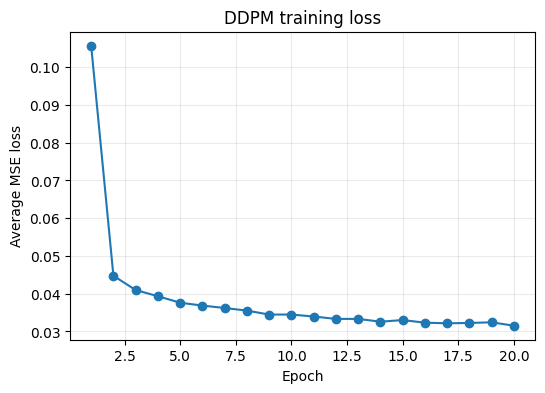

In [12]:

# Plot average training loss

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average MSE loss")
plt.title("DDPM training loss")
plt.grid(alpha=0.25)
plt.show()


In [13]:

@torch.no_grad()
def sample_ddpm(model, n_samples=16, save_intermediates=False):
    model.eval()

    # x_T ~ N(0, I)
    x = torch.randn(
        n_samples,
        1,
        img_size,
        img_size,
        device=device,
    )

    intermediates = {}

    # Nice checkpoints if we want to visualize the denoising trajectory.
    checkpoints = {
        T - 1,
        int(0.75 * T),
        int(0.50 * T),
        int(0.25 * T),
        100,
        0,
    }

    for t in reversed(range(T)):
        t_batch = torch.full(
            (n_samples,),
            t,
            device=device,
            dtype=torch.long,
        )

        eps_pred = model(x, t_batch)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        # Standard DDPM epsilon-prediction reverse mean.
        mean = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            x
            - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred
        )

        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1]

            beta_tilde = (
                beta_t
                * (1.0 - alpha_bar_prev)
                / (1.0 - alpha_bar_t)
            )

            z = torch.randn_like(x)
            x = mean + torch.sqrt(beta_tilde) * z
        else:
            x = mean

        if save_intermediates and t in checkpoints:
            intermediates[t] = x.detach().cpu()

    model.train()

    if save_intermediates:
        return x, intermediates

    return x


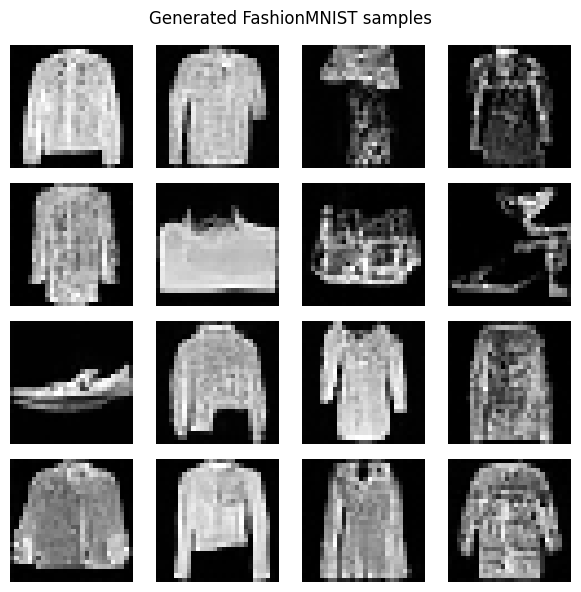

In [14]:

# Generate and plot a 4x4 sample grid

samples = sample_ddpm(model, n_samples=16)

# Model data range is [-1, 1]; convert to [0, 1] for plotting.
samples_vis = (samples.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(samples_vis[i, 0].cpu(), cmap="gray")
    ax.axis("off")

plt.suptitle("Generated FashionMNIST samples")
plt.tight_layout()
plt.show()


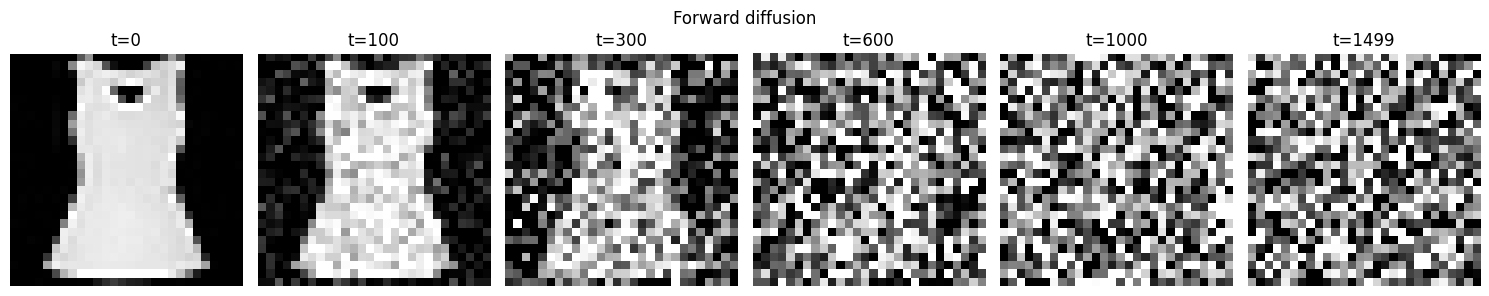

In [15]:

# Visualize forward diffusion of one real image

x0, _ = next(iter(train_loader))
x0 = x0[0:1].to(device)

timesteps = [0, 100, 300, 600, 1000, T - 1]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))

for ax, t_val in zip(axes, timesteps):
    t = torch.tensor([t_val], device=device, dtype=torch.long)

    xt, _ = forward_diffusion(x0, t)

    img = (xt[0, 0].clamp(-1, 1) + 1) / 2

    ax.imshow(img.cpu(), cmap="gray")
    ax.set_title(f"t={t_val}")
    ax.axis("off")

plt.suptitle("Forward diffusion")
plt.tight_layout()
plt.show()


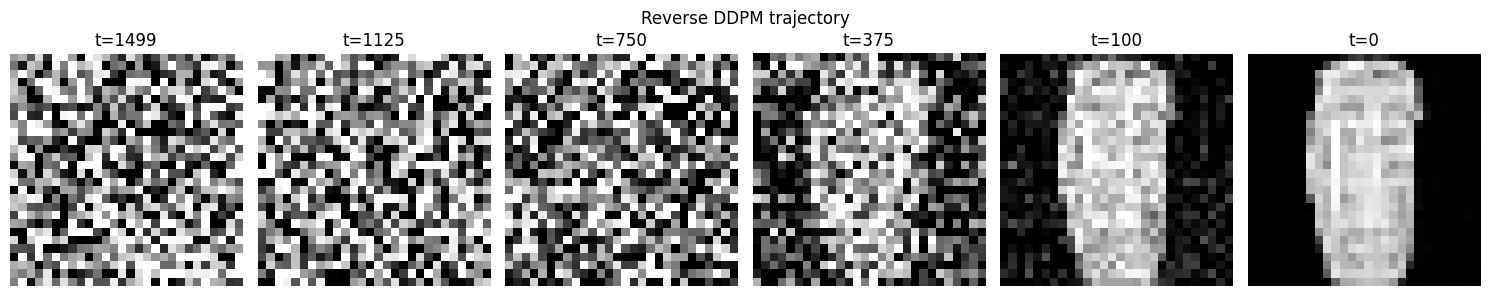

In [16]:

# Visualize one generated sample through the reverse trajectory

final_samples, intermediates = sample_ddpm(
    model,
    n_samples=1,
    save_intermediates=True,
)

ordered_ts = sorted(intermediates.keys(), reverse=True)

fig, axes = plt.subplots(1, len(ordered_ts), figsize=(15, 3))

for ax, t_val in zip(axes, ordered_ts):
    img = intermediates[t_val][0, 0]
    img = (img.clamp(-1, 1) + 1) / 2

    ax.imshow(img, cmap="gray")
    ax.set_title(f"t={t_val}")
    ax.axis("off")

plt.suptitle("Reverse DDPM trajectory")
plt.tight_layout()
plt.show()
